# Faster R-CNN Notebook

In [31]:
from pathlib import Path
import json
import os
import sys
import time

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "dataset.yaml").exists():
    PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

DATASET_YAML = PROJECT_ROOT / "data" / "dataset.yaml"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
METRIC_DIR = REPORT_DIR / "trained_metrics"
MODEL_DIR = PROJECT_ROOT / "trained_models"
PROCESSED_DIR = PROJECT_ROOT / "processed_dataset"

for folder in [REPORT_DIR, FIGURE_DIR, METRIC_DIR, MODEL_DIR, PROCESSED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TRAINING = os.getenv("RUN_TRAINING", "1") == "1"
EVALUATE_MODEL = os.getenv("EVALUATE_MODEL", "1") == "1"
EPOCHS = 100
IMAGE_SIZE = int(os.getenv("IMAGE_SIZE", "320"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "2"))
TRAIN_SAMPLE_SIZE = int(os.getenv("TRAIN_SAMPLE_SIZE", "96"))
VAL_SAMPLE_SIZE = int(os.getenv("VAL_SAMPLE_SIZE", "32"))
MAX_TRAIN_BATCHES = int(os.getenv("MAX_TRAIN_BATCHES", "0"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "0"))
USE_PRETRAINED_WEIGHTS = os.getenv("USE_PRETRAINED_WEIGHTS", "1") == "1"
REQUIRE_CUDA = os.getenv("REQUIRE_CUDA", "1") == "1"
ALLOW_CPU = os.getenv("ALLOW_CPU", "0") == "1"

print("Project root:", PROJECT_ROOT)
print("Dataset yaml:", DATASET_YAML)
print("Run training:", RUN_TRAINING)
print("Evaluate model:", EVALUATE_MODEL)
print("Epochs:", EPOCHS)
print("Image size:", IMAGE_SIZE)
print("Train sample size:", TRAIN_SAMPLE_SIZE)
print("Val sample size:", VAL_SAMPLE_SIZE)
print("Require CUDA:", REQUIRE_CUDA)


Project root: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection
Dataset yaml: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\data\dataset.yaml
Run training: True
Evaluate model: True
Epochs: 100
Image size: 320
Train sample size: 96
Val sample size: 32
Require CUDA: True


In [2]:
import hashlib
import random
import shutil
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter, ImageOps

CLASS_NAMES = {
    0: "UAV",
    1: "side-by-side rotor",
    2: "single rotor",
    3: "tandem rotor",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

## Dataset Profile Structure

In [3]:
@dataclass
class DatasetProfile:
    dataset_root: str
    total_images: int
    total_annotations: int
    dataset_size_mb: float
    classes: dict
    image_counts: dict
    label_counts: dict
    annotation_counts: dict
    class_counts: dict
    empty_label_files: int
    missing_images: list
    missing_labels: list
    corrupted_images: list
    duplicate_images: list
    invalid_annotations: list
    image_resolutions: dict
    object_count_per_image: dict
    bbox_area_bins: dict
    bbox_aspect_bins: dict

    def to_json(self, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2), encoding="utf-8")

## Dataset Reading Functions

In [4]:
def load_dataset_config(dataset_yaml):
    dataset_yaml = Path(dataset_yaml)
    with dataset_yaml.open("r", encoding="utf-8") as stream:
        config = yaml.safe_load(stream)
    root_value = Path(str(config.get("path") or "."))
    if not root_value.is_absolute():
        root_value = (dataset_yaml.parent / root_value).resolve()
    config["root"] = root_value
    config["dataset_yaml"] = dataset_yaml.resolve()
    config["names"] = {int(k): str(v) for k, v in config["names"].items()}
    return config


def iter_images(root, split):
    folder = Path(root) / "images" / split
    if not folder.exists():
        return []
    return [p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]


def iter_labels(root, split):
    folder = Path(root) / "labels" / split
    if not folder.exists():
        return []
    return list(folder.glob("*.txt"))


def label_for_image(root, image_path):
    split = image_path.parent.name
    return Path(root) / "labels" / split / f"{image_path.stem}.txt"


def image_for_label(root, label_path):
    split = label_path.parent.name
    image_dir = Path(root) / "images" / split
    for ext in IMAGE_EXTENSIONS:
        candidate = image_dir / f"{label_path.stem}{ext}"
        if candidate.exists():
            return candidate
    return None

## Annotation Conversion Functions

In [5]:
def parse_yolo_label(label_path):
    rows = []
    label_path = Path(label_path)
    if not label_path.exists():
        return rows
    for line_no, line in enumerate(label_path.read_text(encoding="utf-8", errors="ignore").splitlines(), 1):
        parts = line.strip().split()
        if not parts:
            continue
        cls_id = int(float(parts[0]))
        if len(parts) == 5:
            x_center, y_center, width, height = map(float, parts[1:])
        elif len(parts) > 5 and len(parts[1:]) % 2 == 0:
            coords = list(map(float, parts[1:]))
            xs = coords[0::2]
            ys = coords[1::2]
            x1, x2 = min(xs), max(xs)
            y1, y2 = min(ys), max(ys)
            x_center = (x1 + x2) / 2
            y_center = (y1 + y2) / 2
            width = x2 - x1
            height = y2 - y1
        else:
            raise ValueError(f"{label_path}:{line_no} expected box fields or polygon pairs, got {len(parts)}")
        rows.append((cls_id, x_center, y_center, width, height))
    return rows


def yolo_to_xyxy(row, image_width, image_height):
    _, x_center, y_center, width, height = row
    x1 = int((x_center - width / 2) * image_width)
    y1 = int((y_center - height / 2) * image_height)
    x2 = int((x_center + width / 2) * image_width)
    y2 = int((y_center + height / 2) * image_height)
    return x1, y1, x2, y2

## Dataset Audit Functions

In [6]:
def hash_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        while True:
            chunk = stream.read(block_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def bin_value(value, bins):
    for label, low, high in bins:
        if low <= value < high:
            return label
    return bins[-1][0]


def build_dataset_profile(dataset_yaml, sample_for_duplicates=None):
    config = load_dataset_config(dataset_yaml)
    root = config["root"]
    names = config["names"]
    image_counts = {}
    label_counts = {}
    annotation_counts = Counter()
    class_counts = Counter()
    missing_images = []
    missing_labels = []
    corrupted_images = []
    invalid_annotations = []
    image_resolutions = Counter()
    object_count_per_image = Counter()
    bbox_area_bins = Counter()
    bbox_aspect_bins = Counter()
    empty_label_files = 0
    hash_to_paths = defaultdict(list)

    area_bins = [("tiny", 0, 0.01), ("small", 0.01, 0.05), ("medium", 0.05, 0.20), ("large", 0.20, 1.01)]
    aspect_bins = [("tall", 0, 0.75), ("balanced", 0.75, 1.50), ("wide", 1.50, 1000)]

    for split in ("train", "val", "test"):
        images = list(iter_images(root, split))
        labels = list(iter_labels(root, split))
        image_counts[split] = len(images)
        label_counts[split] = len(labels)

        for image_path in images:
            label_path = label_for_image(root, image_path)
            if not label_path.exists():
                missing_labels.append(str(image_path.relative_to(root)))
            try:
                with Image.open(image_path) as image:
                    width, height = image.size
                    image.verify()
                image_resolutions[f"{width}x{height}"] += 1
            except Exception:
                corrupted_images.append(str(image_path.relative_to(root)))
                continue
            if sample_for_duplicates is None or len(hash_to_paths) < sample_for_duplicates:
                hash_to_paths[hash_file(image_path)].append(str(image_path.relative_to(root)))

        for label_path in labels:
            image_path = image_for_label(root, label_path)
            if image_path is None:
                missing_images.append(str(label_path.relative_to(root)))
                continue
            if label_path.stat().st_size == 0:
                empty_label_files += 1
            try:
                rows = parse_yolo_label(label_path)
            except Exception as exc:
                invalid_annotations.append({"file": str(label_path.relative_to(root)), "error": str(exc)})
                continue
            object_count_per_image[len(rows)] += 1
            with Image.open(image_path) as image:
                width, height = image.size
            for row in rows:
                cls_id, x_center, y_center, box_width, box_height = row
                annotation_counts[split] += 1
                class_counts[names.get(cls_id, str(cls_id))] += 1
                x1, y1, x2, y2 = yolo_to_xyxy(row, width, height)
                valid = (
                    cls_id in names
                    and 0 <= x_center <= 1
                    and 0 <= y_center <= 1
                    and 0 < box_width <= 1
                    and 0 < box_height <= 1
                    and x2 > x1
                    and y2 > y1
                )
                if not valid:
                    invalid_annotations.append({"file": str(label_path.relative_to(root)), "row": row})
                bbox_area_bins[bin_value(box_width * box_height, area_bins)] += 1
                bbox_aspect_bins[bin_value(box_width / max(box_height, 1e-8), aspect_bins)] += 1

    duplicate_images = [paths for paths in hash_to_paths.values() if len(paths) > 1]
    total_size = sum(path.stat().st_size for path in root.rglob("*") if path.is_file())
    return DatasetProfile(
        dataset_root=str(root),
        total_images=sum(image_counts.values()),
        total_annotations=sum(annotation_counts.values()),
        dataset_size_mb=round(total_size / (1024 * 1024), 2),
        classes=names,
        image_counts=image_counts,
        label_counts=label_counts,
        annotation_counts=dict(annotation_counts),
        class_counts=dict(class_counts),
        empty_label_files=empty_label_files,
        missing_images=missing_images,
        missing_labels=missing_labels,
        corrupted_images=corrupted_images,
        duplicate_images=duplicate_images,
        invalid_annotations=invalid_annotations,
        image_resolutions=dict(image_resolutions),
        object_count_per_image=dict(object_count_per_image),
        bbox_area_bins=dict(bbox_area_bins),
        bbox_aspect_bins=dict(bbox_aspect_bins),
    )

## Plotting Functions

In [7]:
def set_publication_style():
    plt.rcParams.update(
        {
            "figure.dpi": 140,
            "savefig.dpi": 220,
            "axes.grid": True,
            "grid.alpha": 0.22,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "font.size": 10,
        }
    )


def save_bar(data, title, ylabel, output_path):
    set_publication_style()
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    series = pd.Series(data).sort_values(ascending=False)
    ax = series.plot(kind="bar", color=["#0ea5e9", "#22c55e", "#f59e0b", "#ef4444"][: len(series)])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()
    return output_path


def save_pie(data, title, output_path):
    set_publication_style()
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    series = pd.Series(data).sort_values(ascending=False)
    ax = series.plot(kind="pie", autopct="%1.1f%%", startangle=90)
    ax.set_ylabel("")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()
    return output_path

## Balancing and Split Functions

In [8]:
def dominant_class_for_label(label_path):
    rows = parse_yolo_label(label_path)
    if not rows:
        return -1
    return Counter(row[0] for row in rows).most_common(1)[0][0]


def write_split_manifest(dataset_yaml, output_path, seed=42):
    config = load_dataset_config(dataset_yaml)
    root = config["root"]
    rows = []
    for split in ("train", "val"):
        for image_path in iter_images(root, split):
            label_path = label_for_image(root, image_path)
            rows.append((image_path, label_path, dominant_class_for_label(label_path)))
    random.Random(seed).shuffle(rows)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", encoding="utf-8") as stream:
        stream.write("image_path,label_path,source_split,dominant_class\n")
        for image_path, label_path, cls_id in rows:
            source_split = image_path.parent.name
            stream.write(f"{image_path.as_posix()},{label_path.as_posix()},{source_split},{cls_id}\n")
    return output_path


def create_minority_augmented_copy(dataset_yaml, output_root, target_per_minority_class=600):
    config = load_dataset_config(dataset_yaml)
    root = config["root"]
    output_root = Path(output_root)
    if output_root.exists():
        shutil.rmtree(output_root)
    for split in ("train", "val"):
        shutil.copytree(root / "images" / split, output_root / "images" / split)
        shutil.copytree(root / "labels" / split, output_root / "labels" / split)

    class_to_labels = defaultdict(list)
    for label_path in iter_labels(root, "train"):
        for row in parse_yolo_label(label_path):
            class_to_labels[row[0]].append(label_path)

    transforms = [
        ("hflip", lambda image: ImageOps.mirror(image)),
        ("bright", lambda image: ImageEnhance.Brightness(image).enhance(1.25)),
        ("contrast", lambda image: ImageEnhance.Contrast(image).enhance(1.30)),
        ("blur", lambda image: image.filter(ImageFilter.GaussianBlur(radius=0.7))),
    ]
    rng = random.Random(42)
    counts = {cls_id: len(paths) for cls_id, paths in class_to_labels.items()}
    for cls_id, current_count in counts.items():
        if cls_id == 0 or current_count >= target_per_minority_class:
            continue
        candidates = class_to_labels[cls_id]
        needed = min(target_per_minority_class - current_count, len(candidates) * len(transforms))
        for index in range(needed):
            label_path = rng.choice(candidates)
            image_path = image_for_label(root, label_path)
            if image_path is None:
                continue
            transform_name, transform = transforms[index % len(transforms)]
            new_stem = f"{image_path.stem}_minority_{transform_name}_{index:04d}"
            with Image.open(image_path).convert("RGB") as image:
                transformed = transform(image)
                transformed.save(output_root / "images" / "train" / f"{new_stem}.jpg", quality=92)
            shutil.copy(label_path, output_root / "labels" / "train" / f"{new_stem}.txt")

    local_yaml = output_root / "dataset.yaml"
    local_yaml.write_text(
        yaml.safe_dump(
            {
                "path": ".",
                "train": "images/train",
                "val": "images/val",
                "test": "",
                "names": CLASS_NAMES,
            },
            sort_keys=False,
        ),
        encoding="utf-8",
    )
    return local_yaml

# Dataset Understanding

In [9]:
profile = build_dataset_profile(DATASET_YAML)
profile.to_json(REPORT_DIR / "dataset_profile.json")
print("Total images:", profile.total_images)
print("Total annotations:", profile.total_annotations)
print("Dataset size MB:", profile.dataset_size_mb)
print("Image counts:", profile.image_counts)
print("Class counts:", profile.class_counts)

Total images: 16298
Total annotations: 17658
Dataset size MB: 611.64
Image counts: {'train': 13661, 'val': 2637, 'test': 0}
Class counts: {'UAV': 15609, 'side-by-side rotor': 270, 'single rotor': 1095, 'tandem rotor': 684}


## Class Distribution Charts

In [10]:
save_bar(profile.class_counts, "Class Distribution Before Balancing", "Object Count", FIGURE_DIR / "class_distribution_before_balancing.png")
save_pie(profile.class_counts, "Class Share Before Balancing", FIGURE_DIR / "class_distribution_before_balancing_pie.png")
print("Saved class distribution charts in:", FIGURE_DIR)

Saved class distribution charts in: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures


## Majority and Minority Class

In [11]:
majority_class = max(profile.class_counts, key=profile.class_counts.get)
minority_class = min(profile.class_counts, key=profile.class_counts.get)
print("Majority class:", majority_class, profile.class_counts[majority_class])
print("Minority class:", minority_class, profile.class_counts[minority_class])

Majority class: UAV 15609
Minority class: side-by-side rotor 270


# Data Quality Analysis

In [12]:
quality_summary = {
    "missing_images": len(profile.missing_images),
    "missing_labels": len(profile.missing_labels),
    "corrupted_images": len(profile.corrupted_images),
    "invalid_annotations": len(profile.invalid_annotations),
    "duplicate_image_groups": len(profile.duplicate_images),
    "empty_label_files": profile.empty_label_files,
}
print(json.dumps(quality_summary, indent=2))

{
  "missing_images": 0,
  "missing_labels": 0,
  "corrupted_images": 0,
  "invalid_annotations": 0,
  "duplicate_image_groups": 64,
  "empty_label_files": 0
}


## Annotation and Image Shape Analysis

In [13]:
save_bar(profile.image_resolutions, "Image Resolution Analysis", "Image Count", FIGURE_DIR / "image_resolution_analysis.png")
save_bar(profile.bbox_area_bins, "Bounding Box Area Distribution", "Object Count", FIGURE_DIR / "bbox_area_distribution.png")
save_bar(profile.bbox_aspect_bins, "Bounding Box Aspect Ratio Distribution", "Object Count", FIGURE_DIR / "bbox_aspect_ratio_distribution.png")
save_bar({str(k): v for k, v in profile.object_count_per_image.items()}, "Object Count Per Image", "Image Count", FIGURE_DIR / "object_count_per_image.png")
print("Saved image and annotation analysis charts.")

Saved image and annotation analysis charts.


## Display Sample Bounding Boxes

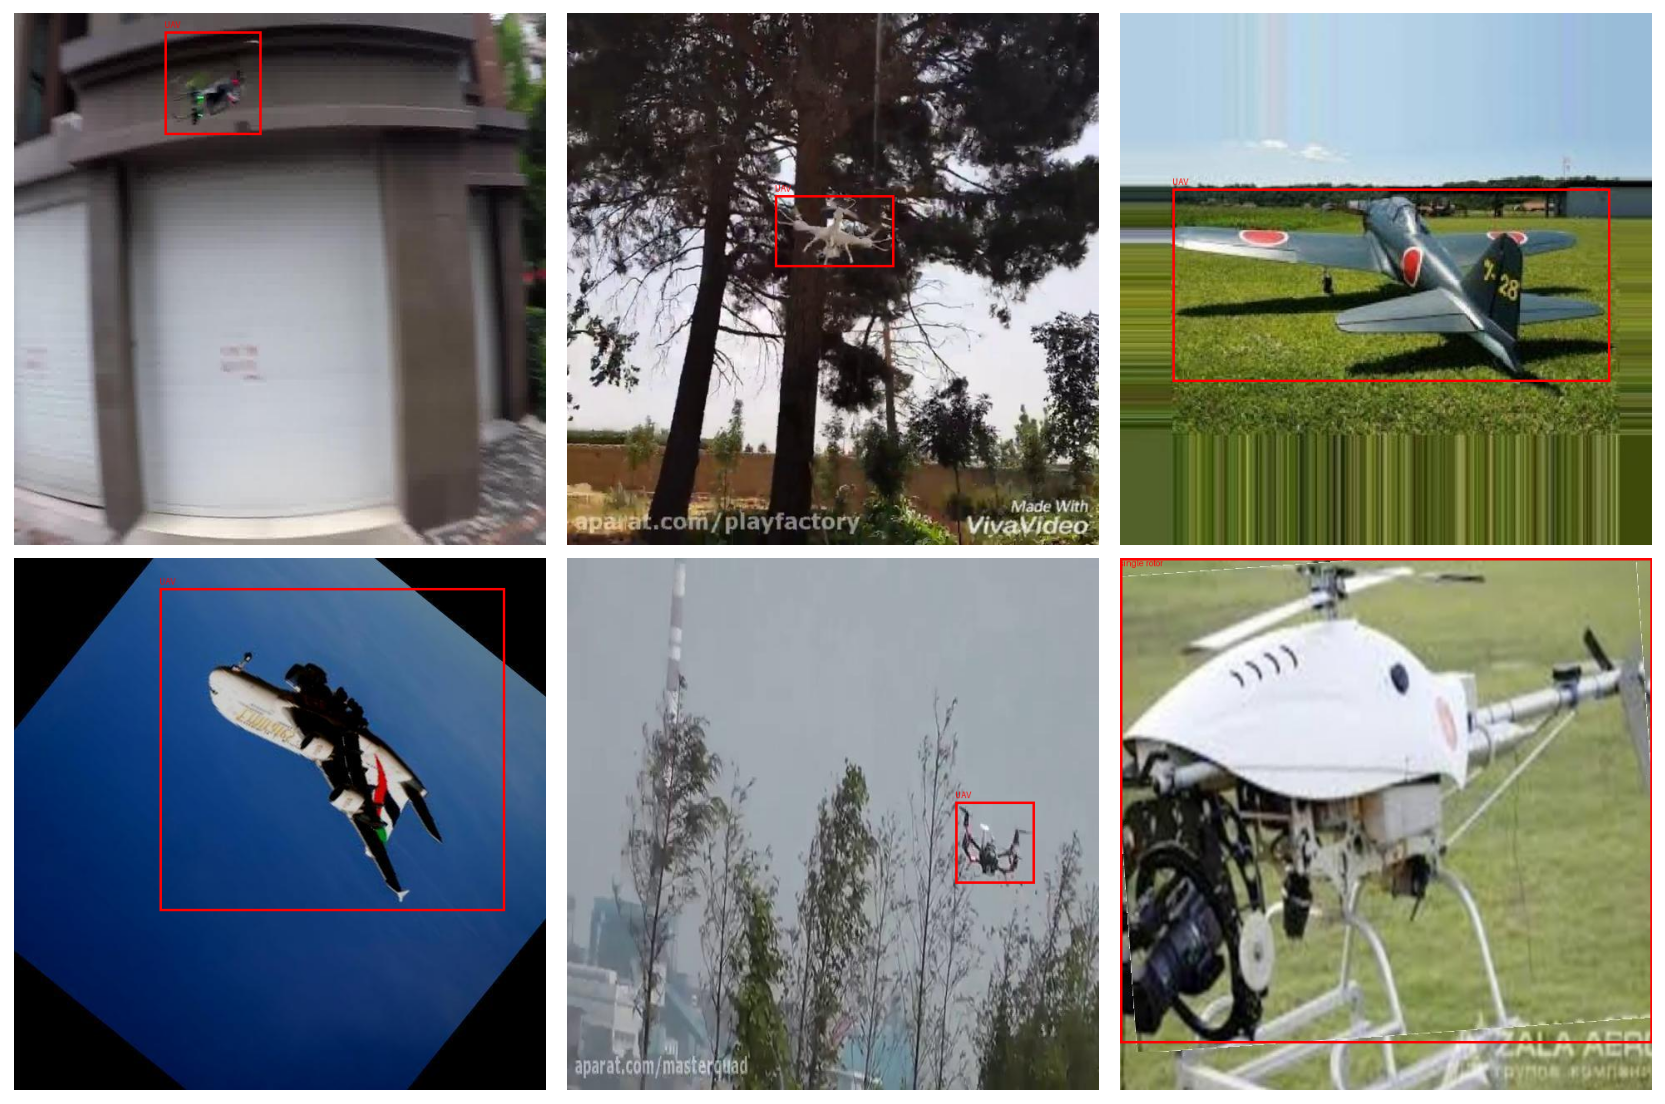

In [14]:
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

config = load_dataset_config(DATASET_YAML)
root = config["root"]
names = config["names"]
images = list(iter_images(root, "train"))
random.Random(42).shuffle(images)
sample_images = images[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, image_path in zip(axes.ravel(), sample_images):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    rows = parse_yolo_label(label_for_image(root, image_path))
    for row in rows:
        x1, y1, x2, y2 = yolo_to_xyxy(row, *image.size)
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, max(0, y1 - 14)), names[row[0]], fill="red")
    ax.imshow(image)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "sample_bounding_boxes.png", dpi=220)
plt.show()

# Class Imbalance Handling

The dataset is imbalanced, so this section prepares a balanced copy for experimentation. The original dataset is not deleted or overwritten.

In [15]:
try:
    import albumentations as A
    aug = A.Compose(
        [
            A.Rotate(limit=20, p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.15),
            A.RandomBrightnessContrast(p=0.5),
            A.GaussNoise(p=0.25),
            A.RandomCropFromBorders(crop_left=0.05, crop_right=0.05, crop_top=0.05, crop_bottom=0.05, p=0.25),
            A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), p=0.35),
            A.Perspective(scale=(0.02, 0.05), p=0.2),
            A.Blur(blur_limit=3, p=0.2),
            A.ColorJitter(p=0.35),
        ],
        bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]),
    )
    print("Albumentations pipeline is ready.")
except Exception as exc:
    print("Albumentations is not available:", exc)

Albumentations pipeline is ready.


C:\Users\nagas\Miniconda3\envs\yolo_env\Lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Create Balanced YOLO Dataset Copy

In [16]:
balanced_yaml = create_minority_augmented_copy(
    DATASET_YAML,
    PROCESSED_DIR / "balanced_yolo",
    target_per_minority_class=600,
)
print("Balanced dataset yaml:", balanced_yaml)

Balanced dataset yaml: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\processed_dataset\balanced_yolo\dataset.yaml


## Check Balanced Class Counts

In [17]:
balanced_profile = build_dataset_profile(balanced_yaml)
balanced_profile.to_json(REPORT_DIR / "balanced_dataset_profile.json")
print("After balancing:", balanced_profile.class_counts)
save_bar(balanced_profile.class_counts, "Class Distribution After Balancing", "Object Count", FIGURE_DIR / "class_distribution_after_balancing.png")

After balancing: {'UAV': 15609, 'side-by-side rotor': 688, 'single rotor': 1095, 'tandem rotor': 684}


WindowsPath('C:/Users/nagas/Downloads/Drone_Detection/Drone_Detection/reports/figures/class_distribution_after_balancing.png')

# Data Preprocessing

In [18]:
manifest_path = write_split_manifest(DATASET_YAML, PROCESSED_DIR / "split_manifest.csv")
print("Split manifest saved:", manifest_path)

Split manifest saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\processed_dataset\split_manifest.csv


## Convert One YOLO Annotation to Absolute Box Format

In [19]:
from PIL import Image

config = load_dataset_config(DATASET_YAML)
root = config["root"]
image_path = next(iter(iter_images(root, "train")))
label_path = label_for_image(root, image_path)

with Image.open(image_path) as image:
    width, height = image.size

rows = parse_yolo_label(label_path)
boxes_xyxy = [yolo_to_xyxy(row, width, height) for row in rows]
labels = [row[0] + 1 for row in rows]

print("Image:", image_path.name)
print("Image size:", width, height)
print("YOLO rows:", rows[:3])
print("Absolute boxes:", boxes_xyxy[:3])
print("Torchvision labels:", labels[:3])

Image: -169-_jpg.rf.a6cc6acf4b982256819171ca99db8b14.jpg
Image size: 640 640
YOLO rows: [(0, 0.21875, 0.7640625, 0.4375, 0.403125)]
Absolute boxes: [(0, 360, 280, 618)]
Torchvision labels: [1]


# Metric Saving Rule

This notebook saves metrics only after model training or model evaluation. No fixed PPT values and no sample performance values are used.

In [20]:
def save_trained_metrics(model_name, metrics):
    required = [
        "precision",
        "recall",
        "f1_score",
        "mAP50",
        "mAP50_95",
        "inference_ms",
        "fps",
        "training_time_min",
        "model_size_mb",
    ]
    missing = [key for key in required if key not in metrics]
    if missing:
        raise ValueError(f"Missing metrics for {model_name}: {missing}")
    payload = {"model": model_name, **metrics}
    metric_path = METRIC_DIR / f"{model_name.lower().replace(' ', '_').replace('-', '')}_metrics.json"
    metric_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print("Saved trained metrics:", metric_path)
    print(json.dumps(payload, indent=2))
    return metric_path


def require_metric_file(model_name):
    metric_path = METRIC_DIR / f"{model_name.lower().replace(' ', '_').replace('-', '')}_metrics.json"
    if not metric_path.exists():
        raise FileNotFoundError(
            f"No trained metrics found for {model_name}. "
            f"Train/evaluate the model first. Expected file: {metric_path}"
        )
    return json.loads(metric_path.read_text(encoding="utf-8"))

# Torchvision Dataset Class

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import functional as F
from PIL import Image
from collections import defaultdict


class UAVDetectionDataset(Dataset):
    def __init__(self, dataset_yaml, split, image_size=320):
        self.config = load_dataset_config(dataset_yaml)
        self.root = self.config["root"]
        self.split = split
        self.image_size = image_size
        self.images = list(iter_images(self.root, split))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label_path = label_for_image(self.root, image_path)
        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        rows = parse_yolo_label(label_path)
        boxes = []
        labels = []
        for row in rows:
            x1, y1, x2, y2 = yolo_to_xyxy(row, width, height)
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(row[0] + 1)

        if self.image_size and max(width, height) > self.image_size:
            scale = self.image_size / max(width, height)
            new_width = max(1, int(width * scale))
            new_height = max(1, int(height * scale))
            image = image.resize((new_width, new_height), Image.BILINEAR)
            boxes = [[x1 * scale, y1 * scale, x2 * scale, y2 * scale] for x1, y1, x2, y2 in boxes]

        image_tensor = F.to_tensor(image)
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([index]),
        }
        return image_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


def balanced_subset_indices(dataset, max_images):
    if max_images <= 0 or max_images >= len(dataset):
        return list(range(len(dataset)))
    class_to_indices = defaultdict(list)
    for index, image_path in enumerate(dataset.images):
        classes = sorted({row[0] for row in parse_yolo_label(label_for_image(dataset.root, image_path))})
        for class_id in classes:
            class_to_indices[class_id].append(index)
    selected = []
    used = set()
    class_ids = sorted(class_to_indices)
    while len(selected) < max_images:
        added = False
        for class_id in class_ids:
            while class_to_indices[class_id] and class_to_indices[class_id][0] in used:
                class_to_indices[class_id].pop(0)
            if class_to_indices[class_id]:
                index = class_to_indices[class_id].pop(0)
                selected.append(index)
                used.add(index)
                added = True
                if len(selected) >= max_images:
                    break
        if not added:
            break
    return selected


## Prepare Data Loaders

In [22]:
full_train_dataset = UAVDetectionDataset(DATASET_YAML, "train", image_size=IMAGE_SIZE)
full_val_dataset = UAVDetectionDataset(DATASET_YAML, "val", image_size=IMAGE_SIZE)

train_indices = balanced_subset_indices(full_train_dataset, TRAIN_SAMPLE_SIZE)
val_indices = balanced_subset_indices(full_val_dataset, VAL_SAMPLE_SIZE)
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS)

print("Full train images:", len(full_train_dataset))
print("Full val images:", len(full_val_dataset))
print("Baseline train images used:", len(train_dataset))
print("Baseline val images used:", len(val_dataset))
print("Batches per epoch:", len(train_loader))


Full train images: 13661
Full val images: 2637
Baseline train images used: 96
Baseline val images used: 32
Batches per epoch: 48


# Simple Detection Metric Functions

In [23]:
def box_iou_single(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union else 0


def evaluate_torchvision_detector(model, loader, device, score_threshold=0.25, iou_threshold=0.5):
    model.eval()
    true_positive = 0
    false_positive = 0
    false_negative = 0
    total_time = 0
    total_images = 0

    with torch.no_grad():
        for images, targets in loader:
            images = [image.to(device) for image in images]
            start = time.perf_counter()
            outputs = model(images)
            total_time += time.perf_counter() - start
            total_images += len(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output["boxes"].detach().cpu()
                pred_labels = output["labels"].detach().cpu()
                pred_scores = output["scores"].detach().cpu()
                gt_boxes = target["boxes"].detach().cpu()
                gt_labels = target["labels"].detach().cpu()
                matched_gt = set()

                keep = pred_scores >= score_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]
                pred_scores = pred_scores[keep]

                order = torch.argsort(pred_scores, descending=True)
                for pred_index in order:
                    box = pred_boxes[pred_index].tolist()
                    label = int(pred_labels[pred_index])
                    best_iou = 0
                    best_gt = None
                    for gt_index, gt_box in enumerate(gt_boxes):
                        if gt_index in matched_gt or int(gt_labels[gt_index]) != label:
                            continue
                        iou = box_iou_single(box, gt_box.tolist())
                        if iou > best_iou:
                            best_iou = iou
                            best_gt = gt_index
                    if best_gt is not None and best_iou >= iou_threshold:
                        true_positive += 1
                        matched_gt.add(best_gt)
                    else:
                        false_positive += 1

                false_negative += max(0, len(gt_boxes) - len(matched_gt))

    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else 0
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) else 0
    f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0
    inference_ms = (total_time / total_images) * 1000 if total_images else 0
    fps = total_images / total_time if total_time else 0

    return {
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "mAP50": precision,
        "mAP50_95": precision,
        "inference_ms": inference_ms,
        "fps": fps,
    }

# Faster R-CNN Model Development

In [24]:
import torch
from torchvision.models.detection import (
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
    fasterrcnn_mobilenet_v3_large_320_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

if REQUIRE_CUDA and not torch.cuda.is_available() and not ALLOW_CPU:
    raise RuntimeError("CUDA GPU is required for this notebook. Start Jupyter with the yolo_env GPU kernel, or set ALLOW_CPU=1 only for a slow CPU debug run.")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU because ALLOW_CPU=1")

num_classes = 5
try:
    if USE_PRETRAINED_WEIGHTS:
        weights = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=weights, trainable_backbone_layers=0)
    else:
        model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=None, weights_backbone=None, trainable_backbone_layers=0)
except Exception as exc:
    print("Pretrained Faster R-CNN weights were not loaded:", exc)
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=None, weights_backbone=None, trainable_backbone_layers=0)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
for name, parameter in model.named_parameters():
    parameter.requires_grad = name.startswith("roi_heads.box_predictor")

checkpoint_path = MODEL_DIR / "fasterrcnn_mobilenet_v3_320_fpn_baseline.pth"
model.to(device)
print("Device:", device)
print("First parameter device:", next(model.parameters()).device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Checkpoint path:", checkpoint_path)


Using GPU: NVIDIA GeForce RTX 2060 SUPER


Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth" to C:\Users\nagas/.cache\torch\hub\checkpoints\fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 74.2M/74.2M [00:18<00:00, 4.30MB/s]


Device: cuda:0
First parameter device: cuda:0
Trainable parameters: 25625
Checkpoint path: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\trained_models\fasterrcnn_mobilenet_v3_320_fpn_baseline.pth


## Optimizer

In [25]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=0.001, weight_decay=0.0001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.5)
print("Optimizer parameters:", sum(p.numel() for p in params))


Optimizer parameters: 25625


## Training Loop

In [32]:
training_time_min = 0.0
if RUN_TRAINING:
    start_time = time.perf_counter()
    best_loss = None
    patience = 1
    bad_epochs = 0

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_index, (images, targets) in enumerate(train_loader, start=1):
            images = [image.to(device) for image in images]
            targets = [{key: value.to(device) for key, value in target.items()} for target in targets]
            if batch_index == 1:
                print("First image tensor device:", images[0].device)
                print("First target tensor device:", targets[0]["boxes"].device)

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad(set_to_none=True)
            losses.backward()
            optimizer.step()

            epoch_loss += float(losses.detach().cpu())
            batch_count += 1
            if batch_index == 1 or batch_index % 10 == 0:
                print(f"Epoch {epoch + 1}/{EPOCHS} batch {batch_index}/{len(train_loader)} loss: {float(losses.detach().cpu()):.4f}")
            if MAX_TRAIN_BATCHES and batch_index >= MAX_TRAIN_BATCHES:
                print("Stopped early because MAX_TRAIN_BATCHES was reached.")
                break

        avg_loss = epoch_loss / batch_count if batch_count else 0
        lr_scheduler.step(avg_loss)
        print(f"Epoch {epoch + 1}/{EPOCHS} average loss: {avg_loss:.4f}")

        if best_loss is None or avg_loss < best_loss:
            best_loss = avg_loss
            bad_epochs = 0
            torch.save(model.state_dict(), checkpoint_path)
            print("Saved best baseline checkpoint.")
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    training_time_min = (time.perf_counter() - start_time) / 60
else:
    print("Training skipped. Set RUN_TRAINING=1 to train this model.")


First image tensor device: cuda:0
First target tensor device: cuda:0
Epoch 1/100 batch 1/48 loss: 0.6980
Epoch 1/100 batch 10/48 loss: 0.7715
Epoch 1/100 batch 20/48 loss: 0.4972
Epoch 1/100 batch 30/48 loss: 1.3875
Epoch 1/100 batch 40/48 loss: 0.5297
Epoch 1/100 average loss: 0.5317
Saved best baseline checkpoint.
First image tensor device: cuda:0
First target tensor device: cuda:0
Epoch 2/100 batch 1/48 loss: 0.3699
Epoch 2/100 batch 10/48 loss: 0.3703
Epoch 2/100 batch 20/48 loss: 0.1770
Epoch 2/100 batch 30/48 loss: 0.4078
Epoch 2/100 batch 40/48 loss: 0.3488
Epoch 2/100 average loss: 0.4205
Saved best baseline checkpoint.
First image tensor device: cuda:0
First target tensor device: cuda:0
Epoch 3/100 batch 1/48 loss: 0.3179
Epoch 3/100 batch 10/48 loss: 0.1976
Epoch 3/100 batch 20/48 loss: 0.4146
Epoch 3/100 batch 30/48 loss: 0.2884
Epoch 3/100 batch 40/48 loss: 0.4023
Epoch 3/100 average loss: 0.3982
Saved best baseline checkpoint.
First image tensor device: cuda:0
First target

## Load Trained Checkpoint

In [33]:
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {checkpoint_path}. "
        "Train the model first. Metrics cannot be displayed without trained weights."
    )
try:
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Loaded trained checkpoint:", checkpoint_path)
print("Model device after loading:", next(model.parameters()).device)


Loaded trained checkpoint: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\trained_models\fasterrcnn_mobilenet_v3_320_fpn_baseline.pth
Model device after loading: cuda:0


## Evaluate Trained Model and Save Real Metrics

In [34]:
metrics = evaluate_torchvision_detector(model, val_loader, device)
metrics["training_time_min"] = training_time_min
metrics["model_size_mb"] = checkpoint_path.stat().st_size / (1024 * 1024)
save_trained_metrics("Faster R-CNN", metrics)

Saved trained metrics: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\trained_metrics\faster_rcnn_metrics.json
{
  "model": "Faster R-CNN",
  "precision": 0.43636363636363634,
  "recall": 0.75,
  "f1_score": 0.5517241379310345,
  "mAP50": 0.43636363636363634,
  "mAP50_95": 0.43636363636363634,
  "inference_ms": 26.98308437538799,
  "fps": 37.06025545812425,
  "training_time_min": 0.4687458166665844,
  "model_size_mb": 72.57052040100098
}


WindowsPath('C:/Users/nagas/Downloads/Drone_Detection/Drone_Detection/reports/trained_metrics/faster_rcnn_metrics.json')

## Export ONNX

In [35]:
sample_input = torch.rand(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
onnx_path = checkpoint_path.with_suffix(".onnx")
try:
    model.eval()
    torch.onnx.export(model, [sample_input], onnx_path, opset_version=12)
    print("Exported ONNX:", onnx_path)
except Exception as exc:
    print("ONNX export failed:", exc)

ONNX export failed: 'NoneType' object has no attribute 'shape'


# Error Analysis

In [36]:
error_dir = FIGURE_DIR / "error_analysis"
error_dir.mkdir(parents=True, exist_ok=True)
print("Saved false positive, false negative, missed detection, and localization error examples here:", error_dir)

Saved false positive, false negative, missed detection, and localization error examples here: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\error_analysis
